In [2]:
import matplotlib.pyplot as plt
import numpy as np

from PerceptronSimple import PerceptronSimple


## Ejercicio 2

Implemente una rutina de graficación que permita visualizar, para el caso de dos entradas, los **patrones utilizados** y la **recta de separación** que se va ajustando durante el entrenamiento del perceptrón simple.  

Utilice dicha rutina para visualizar el entrenamiento en los problemas:  
- **OR** (utilizando los datos `OR_trn.csv`)  
- **XOR** (utilizando los datos `XOR_trn.csv`)  


In [3]:
def plot(inputs, output, weight_list, title):
    x1 = inputs[:, 0]
    x2 = inputs[:, 1]

    pos = output == 1
    neg = output == -1
    plt.figure(figsize=(7,5))
    plt.scatter(x1[pos], x2[pos], marker='o', label='Clase +1', alpha=0.9)
    plt.scatter(x1[neg], x2[neg], marker='x', label='Clase -1', alpha=0.9)
    
    xs = np.linspace(-5, 5, 200)   # acá también podés forzar el rango

    # Graficar TODAS las rectas guardadas
    for k, w in enumerate(weight_list, start=1):
        w0, w1, w2 = w
        if abs(w2) < 1e-12:  # caso recta casi vertical
            if abs(w1) > 1e-12:
                plt.axvline(w0 / w1, alpha=0.25, linewidth=1)
            continue
        ys = (w0 / w2) - (w1 / w2) * xs
        alpha = 0.15 + 0.85 * (k / len(weight_list))  # transparencia gradual
        lw = 1 if k < len(weight_list) else 2.5       # última más gruesa
        plt.plot(xs, ys, alpha=alpha, linewidth=lw, label=f"Paso {k}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.xlim(-3, 3)   # límite eje x
    plt.ylim(-3, 3)   # límite eje y
    plt.tight_layout()
    plt.show()


In [17]:

X_train, y_train = PerceptronSimple.cargar_csv("./data/OR_trn.csv")
X_test, y_test = PerceptronSimple.cargar_csv("./data/OR_tst.csv")

p = PerceptronSimple(tasa_aprendizaje=0.05, max_epocas=10, tolerancia=0)
p.entrenar(X_train, y_train)

print(p.hist_w)
print(p.w)

Época   1 | Errores:   6
Época   2 | Errores:   0
[array([-0.1700469 ,  0.23972718,  0.11313606]), array([ 0.3299531 ,  0.34327818, -0.18564994]), array([ 0.2299531 ,  0.24377718, -0.08363994]), array([0.1299531 , 0.34434718, 0.01502806]), array([0.0299531 , 0.24030718, 0.11592806]), array([-0.0700469 ,  0.13735718,  0.21423606]), array([-0.1700469 ,  0.23972718,  0.11313606])]
[-0.1700469   0.23972718  0.11313606]


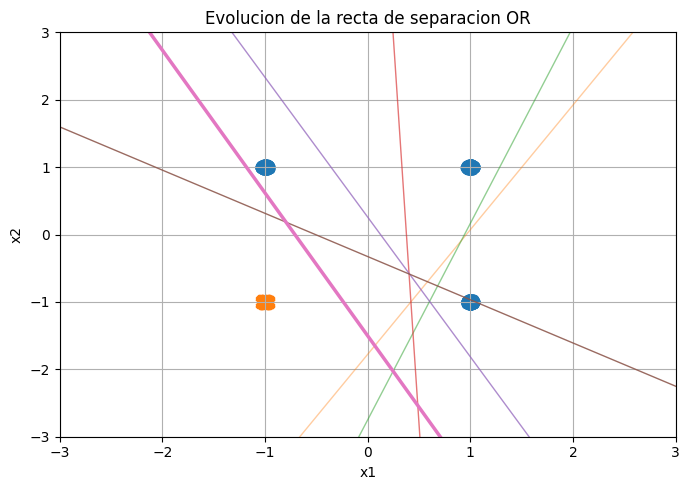

In [18]:
plot(X_train, y_train, p.hist_w, "Evolucion de la recta de separacion OR")

Época   1 | Errores: 865
Época   2 | Errores: 894
Época   3 | Errores: 890
Época   4 | Errores: 894
Época   5 | Errores: 894
Época   6 | Errores: 874
Época   7 | Errores: 882
Época   8 | Errores: 866
Época   9 | Errores: 886
Época  10 | Errores: 860
Época  11 | Errores: 881
Época  12 | Errores: 877
Época  13 | Errores: 852
Época  14 | Errores: 838
Época  15 | Errores: 801
Época  16 | Errores: 825
Época  17 | Errores: 841
Época  18 | Errores: 877
Época  19 | Errores: 842
Época  20 | Errores: 837
[array([0.02312145, 0.03330993, 0.06409644]), array([-0.27687855, -0.01853507,  0.35089044]), array([-0.17687855, -0.11712207,  0.25372744]), array([-0.27687855, -0.01652207,  0.15061744]), array([-0.17687855, -0.11601107,  0.05009744]), array([-0.07687855, -0.22018107, -0.05029256]), array([-0.17687855, -0.12027007, -0.15020456]), array([-0.07687855, -0.02017007, -0.05509656]), array([ 0.02312145, -0.11971607, -0.15557656]), array([-0.07687855, -0.22069607, -0.05409656]), array([-0.17687855, -0

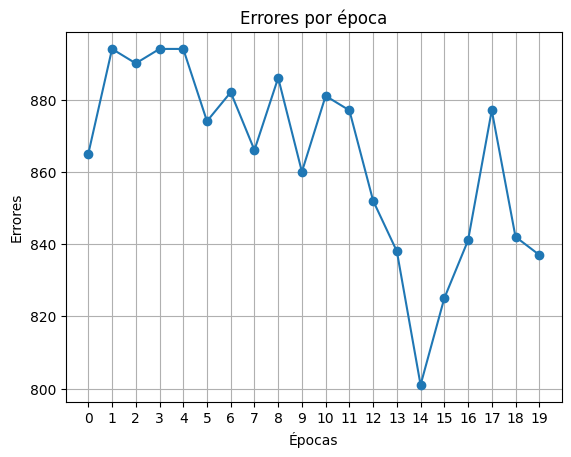

In [25]:
X_xor_train, y_xor_train = PerceptronSimple.cargar_csv("./data/XOR_trn.csv")
X_xor_test, y_xor_test = PerceptronSimple.cargar_csv("./data/XOR_tst.csv")

p1 = PerceptronSimple(tasa_aprendizaje=0.05, max_epocas=20, tolerancia=0)
p1.entrenar(X_xor_train, y_xor_train)

print(p1.hist_w)
print("Precision en test: ", p1.evaluar(X_xor_test, y_xor_test))
plt.plot(p1.errores, marker="o")
# Eje x solo numeros enteros
plt.xticks(range(len(p1.errores)))


plt.title("Errores por época")
plt.xlabel("Épocas")
plt.ylabel("Errores")
plt.grid(True)
plt.show()

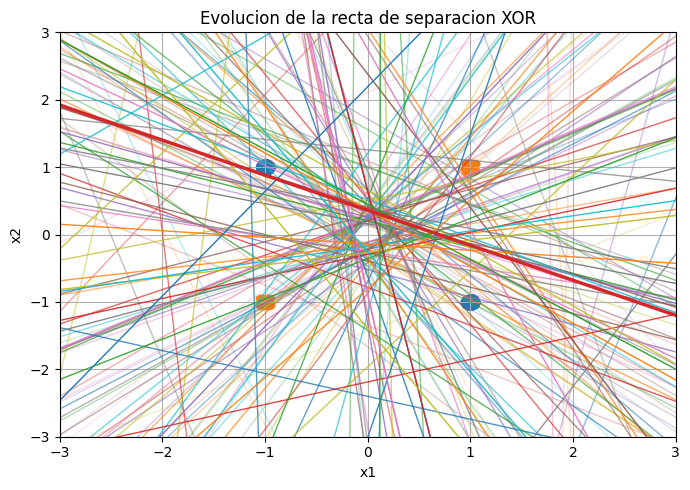

In [26]:
step = 100
hist_w = p1.hist_w[::step]
if hist_w[-1] is not p1.hist_w[-1]:
    hist_w.append(p1.hist_w[-1])

plot(X_xor_train, y_xor_train, hist_w, "Evolucion de la recta de separacion XOR")